# Simple Graphs

In [1]:
import numpy as np,pandas as pd,networkx as nx,matplotlib.pyplot as plt
K=np.array([[1,-1,0,0],
            [1,0,-1,0],
            [0,1,-1,0],
            [0,0,1,-1]]).T
K

array([[ 1,  1,  0,  0],
       [-1,  0,  1,  0],
       [ 0, -1, -1,  1],
       [ 0,  0,  0, -1]])

In [2]:
L=K.dot(K.T)
L

array([[ 2, -1, -1,  0],
       [-1,  2, -1,  0],
       [-1, -1,  3, -1],
       [ 0,  0, -1,  1]])

# Graph Object
## Examining Elements Of Graph

In [3]:
G=nx.Graph()
G.add_node(1)
G.add_node(2,country='DE')
G.add_nodes_from([3,4])
G.add_nodes_from([(5,{'color':'red'}),
                  (6,{'color':'green'})])
G.add_edge(1,2)
G.add_edge(3,4,weight=2)
G.add_edges_from([(1,3),
                  (2,5)])
G.add_edges_from([(2,3,{'weight':3})])
G.nodes

NodeView((1, 2, 3, 4, 5, 6))

In [4]:
G.number_of_nodes()

6

In [5]:
G.edges

EdgeView([(1, 2), (1, 3), (2, 5), (2, 3), (3, 4)])

In [6]:
G.number_of_edges()

5

## Accessing Graph Elements

In [7]:
G.edges[2,3]

{'weight': 3}

In [8]:
G.edges[2,3]['weight']

3

In [9]:
G[1]

AtlasView({2: {}, 3: {}})

## Visualising Graphs

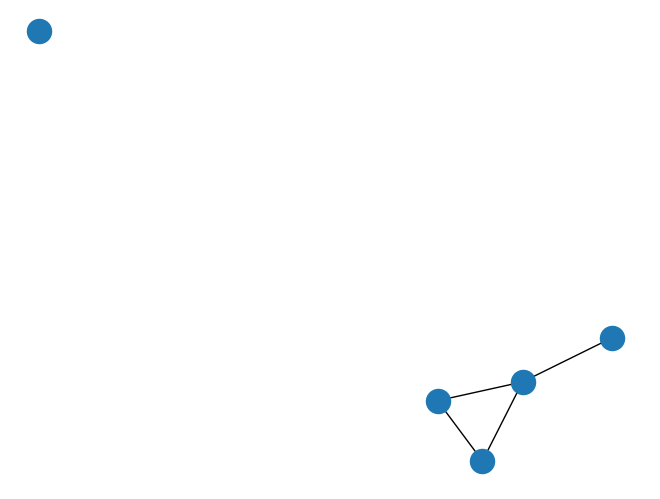

In [10]:
G.remove_node(5)
nx.draw(G)

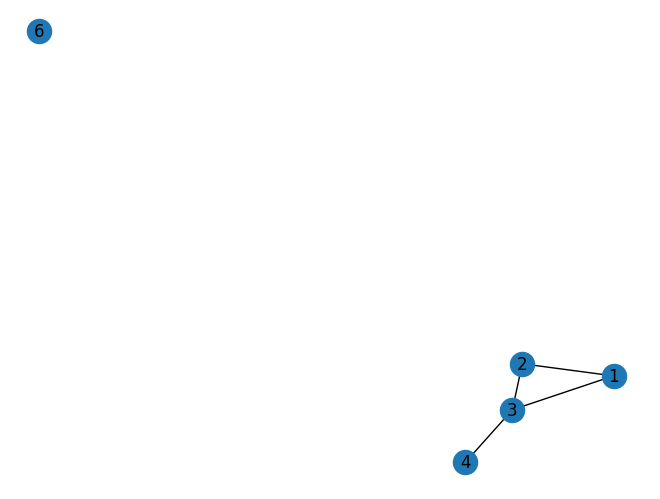

In [11]:
nx.draw(G,with_labels=True)

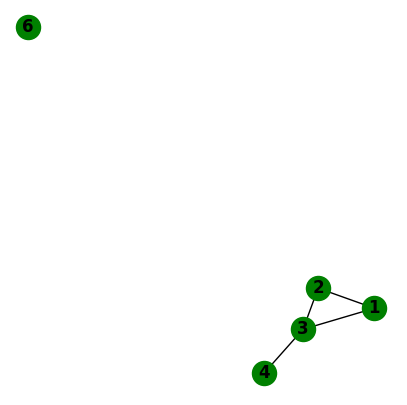

In [12]:
fig,ax=plt.subplots(figsize=(5,5))
nx.draw(G,with_labels=True,ax=ax,node_color='green',font_weight='bold')

## Analysing Graphs

In [13]:
nx.is_connected(G)

False

In [14]:
list(nx.connected_components(G))

[{1, 2, 3, 4}, {6}]

In [15]:
nx.is_planar(G)

True

In [16]:
nx.degree_histogram(G)

[1, 1, 2, 1]

In [17]:
pd.Series(nx.degree_histogram(G))

0    1
1    1
2    2
3    1
dtype: int64

In [18]:
A=nx.adjacency_matrix(G,weight=None).todense()
A

array([[0, 1, 1, 0, 0],
       [1, 0, 1, 0, 0],
       [1, 1, 0, 1, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0]])

In [19]:
nx.incidence_matrix(G,oriented=True).todense()

array([[-1., -1.,  0.,  0.],
       [ 1.,  0., -1.,  0.],
       [ 0.,  1.,  1., -1.],
       [ 0.,  0.,  0.,  1.],
       [ 0.,  0.,  0.,  0.]])

In [20]:
L=nx.laplacian_matrix(G,weight=None).todense()
L

array([[ 2, -1, -1,  0,  0],
       [-1,  2, -1,  0,  0],
       [-1, -1,  3, -1,  0],
       [ 0,  0, -1,  1,  0],
       [ 0,  0,  0,  0,  0]])

In [21]:
nx.cycle_basis(G)

[[1, 2, 3]]

# Example: European Transmission Network

In [22]:
url='data/nodes.csv'
nodes=pd.read_csv(url,index_col=0)
nodes.head(5)

,x,y
Bus,,
8838,-2.169800,53.243852
7157,11.927347,45.403086
1316,14.475861,40.761821
7421,4.520127,50.488619
1317,14.639282,40.688969


In [23]:
url='data/edges.csv'
edges=pd.read_csv(url,index_col=0)
edges.head(5)

,bus0,bus1,s_nom,x_pu
Line,,,,
8968,1771,1774,491.556019,0.000256
11229,3792,3794,3396.205223,0.000017
11228,3793,3794,3396.205223,0.000012
11227,3793,3796,3396.205223,0.000031
8929,927,929,491.556019,0.000092


In [24]:
N=nx.from_pandas_edgelist(edges,'bus0','bus1',edge_attr=['x_pu','s_nom'])
N

Text(0, 0.5, 'Number of nodes')

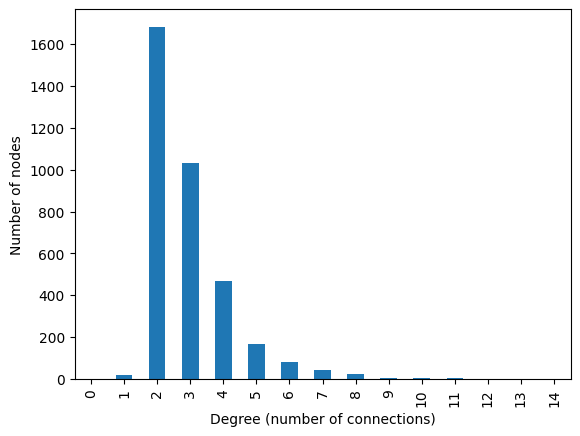

In [25]:
pd.Series(nx.degree_histogram(N)).plot.bar()
plt.xlabel('Degree (number of connections)')
plt.ylabel('Number of nodes')

In [26]:
degrees=[val for node, val in N.degree()]
np.mean(degrees)

np.float64(2.920158550396376)

In [27]:
pos=nodes.apply(tuple,axis=1).to_dict()
{k:pos[k] for k in list(pos.keys())[:5]}

{8838: (-2.16979999999999, 53.243852),
 7157: (11.9273472385104, 45.403085502256),
 1316: (14.475861, 40.761821),
 7421: (4.52012724307074, 50.4886188621382),
 1317: (14.639282, 40.688969)}

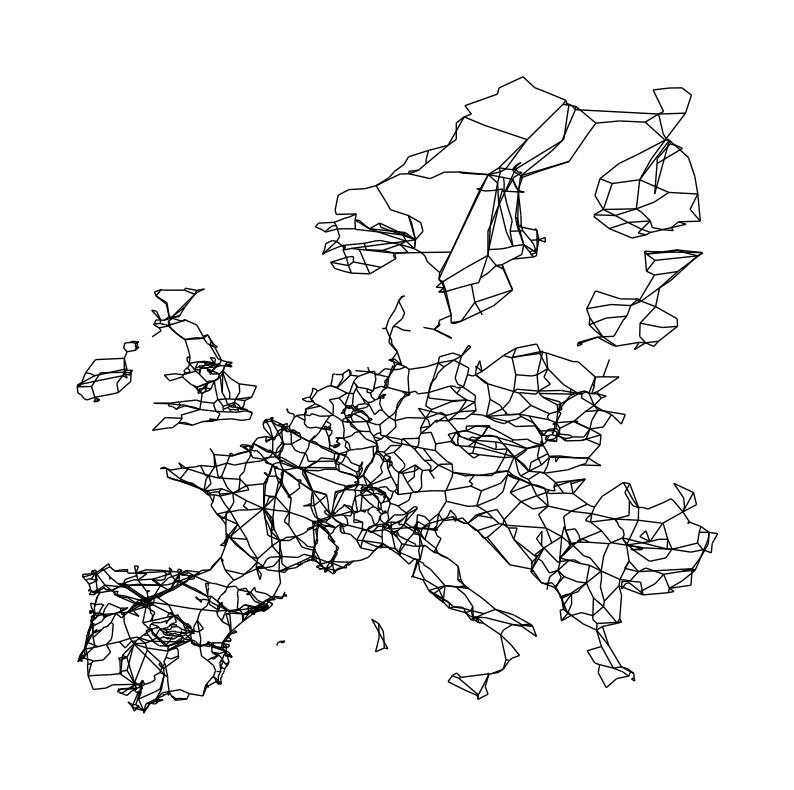

In [28]:
fig,ax=plt.subplots(figsize=(10,10))
nx.draw(N,pos=pos,node_size=0)

In [29]:
len(list(nx.connected_components(N)))

7

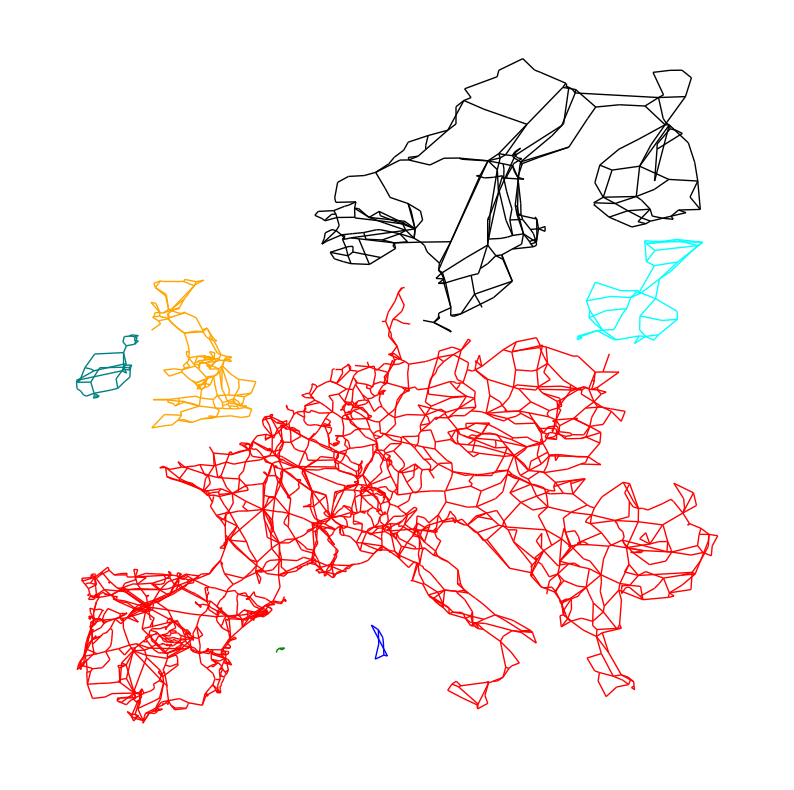

In [30]:
subgraphs=[]
for c in nx.connected_components(N):
    subgraphs.append(N.subgraph(c).copy())
fig,ax=plt.subplots(figsize=(10,10))
colors=['red','blue','green','orange','teal','cyan','black']
for i,sub in enumerate(subgraphs):
    sub_pos={k:v for k,v in pos.items() if k in sub.nodes}
    nx.draw(sub,pos=sub_pos,node_size=0,edge_color=colors[i])

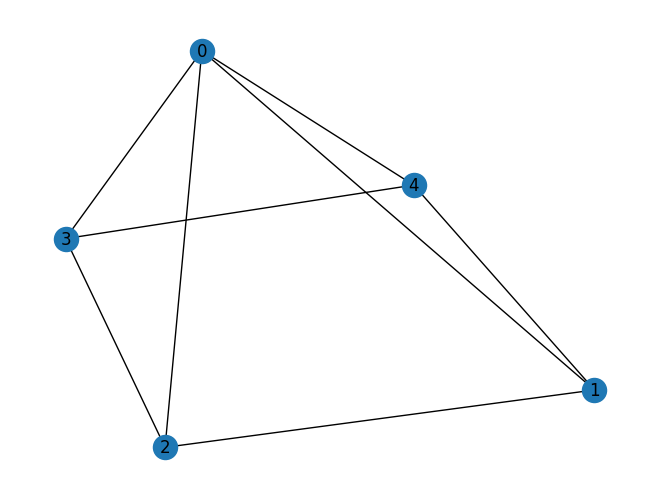

In [31]:
G=nx.Graph()
edges=[(0,1,dict(weight=1)),
       (0,2,dict(weight=2)),
       (0,3,dict(weight=3)),
       (0,4,dict(weight=4)),
       (1,2,dict(weight=3)),
       (1,4,dict(weight=5)),
       (2,3,dict(weight=5)),
       (3,4,dict(weight=7))]
G.add_edges_from(edges)
nx.draw(G,with_labels=True)

In [32]:
G=N
subgraphs=[]
for c in nx.connected_components(G):
    subgraphs.append(G.subgraph(c).copy())
G=subgraphs[3]
len(G.edges)

408

In [33]:
len(G.nodes)

286

In [34]:
pd.Series({k:v for k,v in G.degree}).mean()

np.float64(2.8531468531468533)

In [35]:
len(nx.cycle_basis(G))

123

<Axes: ylabel='Frequency'>

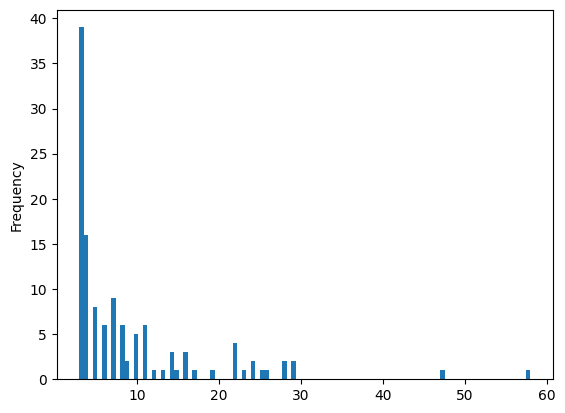

In [36]:
cycle_length=pd.Series([len(c) for c in nx.cycle_basis(G)])
cycle_length.plot.hist(bins=100)

<Axes: >

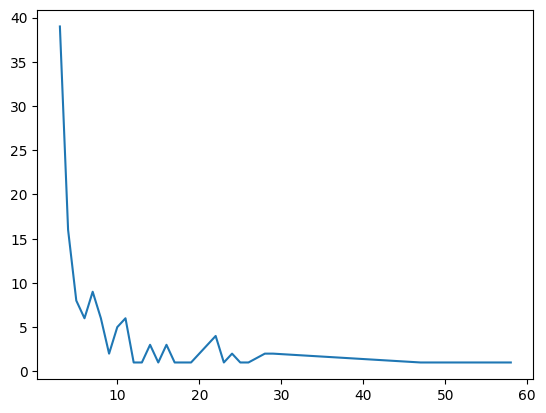

In [37]:
pd.Series([len(c) for c in nx.cycle_basis(G)]).value_counts().sort_index().plot()

In [38]:
cycle_length.describe()

count    123.000000
mean       8.918699
std        8.933813
min        3.000000
25%        3.000000
50%        5.000000
75%       11.000000
max       58.000000
dtype: float64

In [39]:
nx.adjacency_matrix(G).todense()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(286, 286))

In [40]:
K=nx.incidence_matrix(G).todense()
K

array([[1., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(286, 408))